## Healthcare Readmission Analytics

### Notebook 03 — Exploratory Healthcare Analytics

#### Purpose

This notebook explores healthcare patterns in the cleaned dataset.

The main goals are:

- analyze readmission trends
- understand patient demographics
- examine hospital utilization
- identify early healthcare KPIs
- prepare insights for SQL, Power BI, Streamlit, and Machine Learning

#### Why This Matters

Exploratory Data Analysis helps convert raw data into business understanding.

Before building dashboards or machine learning models, we need to understand what patterns exist in the data.

#### Step 1: Import Libraries

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

#### Step 2: Chart Styling

In [2]:
# ============================================
# VISUAL SETTINGS
# ============================================

sns.set_theme(
    style="whitegrid",
    palette="Set2",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

#### Step 3: Load Cleaned Dataset
#####
This notebook uses the cleaned dataset created in Notebook 02.

Using the processed dataset ensures that all future analysis is consistent and reproducible.

In [3]:
# ============================================
# LOAD CLEANED DATASET
# ============================================

data_path = "../data/processed/cleaned_healthcare_data.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (101766, 47)


#### Step 4: Readmission Distribution
#####
The readmission column is the main outcome variable for this project.

It shows whether a patient was:

- not readmitted
- readmitted after 30 days
- readmitted within 30 days

This is important because hospital readmissions are a key healthcare quality and cost metric.

In [4]:
# ============================================
# READMISSION COUNTS
# ============================================

readmission_counts = df["readmitted"].value_counts()

readmission_counts

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

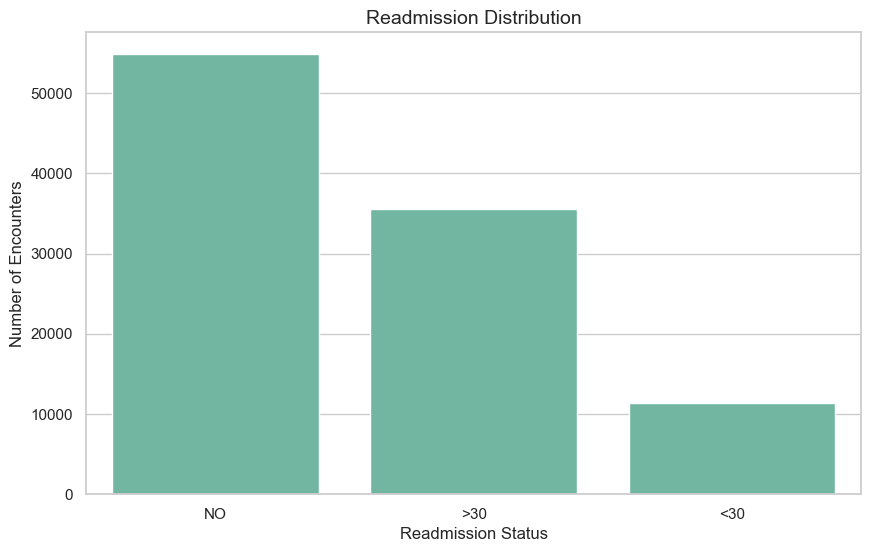

In [5]:
# ============================================
# READMISSION DISTRIBUTION CHART
# ============================================

sns.countplot(
    data=df,
    x="readmitted",
    order=df["readmitted"].value_counts().index
)

plt.title("Readmission Distribution")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Encounters")
plt.show()

#### Healthcare Business Interpretation
Readmission Counts
| Category            |  Count |
| ------------------- | -----: |
| No Readmission      | 54,864 |
| Readmitted >30 Days | 35,545 |
| Readmitted <30 Days | 11,357 |

#### Step 5: Readmission Percentage

In [6]:
# ============================================
# READMISSION PERCENTAGE
# ============================================

readmission_percent = (
    df["readmitted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmission_percent

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

#### Business Interpretation
#####
Readmission Percentages
| Category            | Percentage |
| ------------------- | ---------: |
| No Readmission      |     53.91% |
| Readmitted >30 Days |     34.93% |
| Readmitted <30 Days |     11.16% |

This output shows the percentage of encounters in each readmission category.

The `<30` group is especially important because early readmissions are often monitored as a healthcare quality indicator.

#### Step 6: Create Binary Readmission Flag
#####
For business analysis and machine learning, we create a simplified readmission flag.

- 1 means the patient was readmitted
- 0 means the patient was not readmitted

This makes KPI calculations and ML modeling easier.

In [7]:
# ============================================
# CREATE BINARY READMISSION FLAG
# ============================================

df["readmitted_flag"] = df["readmitted"].apply(
    lambda x: 0 if x == "NO" else 1
)

df["readmitted_flag"].value_counts()

readmitted_flag
0    54864
1    46902
Name: count, dtype: int64

#### Step 7: Overall Readmission Rate KPI

In [8]:
# ============================================
# OVERALL READMISSION RATE
# ============================================

overall_readmission_rate = df["readmitted_flag"].mean() * 100

print(f"Overall Readmission Rate: {overall_readmission_rate:.2f}%")

Overall Readmission Rate: 46.09%


#### KPI Interpretation
#####
Overall Readmission Rate is 46.09%.

Almost 1 out of every 2 encounters resulted in a future readmission.

This immediately validates the business problem and gives a strong justification for machine learning later in the project.

The overall readmission rate is one of the main KPIs for this project.

This metric will later be used in:

- Power BI KPI cards
- Streamlit dashboard metrics
- SQL dashboard views
- machine learning business context

#### Demographic Analysis

#### Age Distribution Analysis
#####
Age is one of the most important healthcare variables.

Understanding patient age distribution helps identify:

- high-utilization age groups
- elderly patient populations
- potential readmission risk segments

Age may later become an important machine learning feature.

In [9]:
# ============================================
# AGE DISTRIBUTION
# ============================================

age_counts = df["age"].value_counts()

age_counts

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

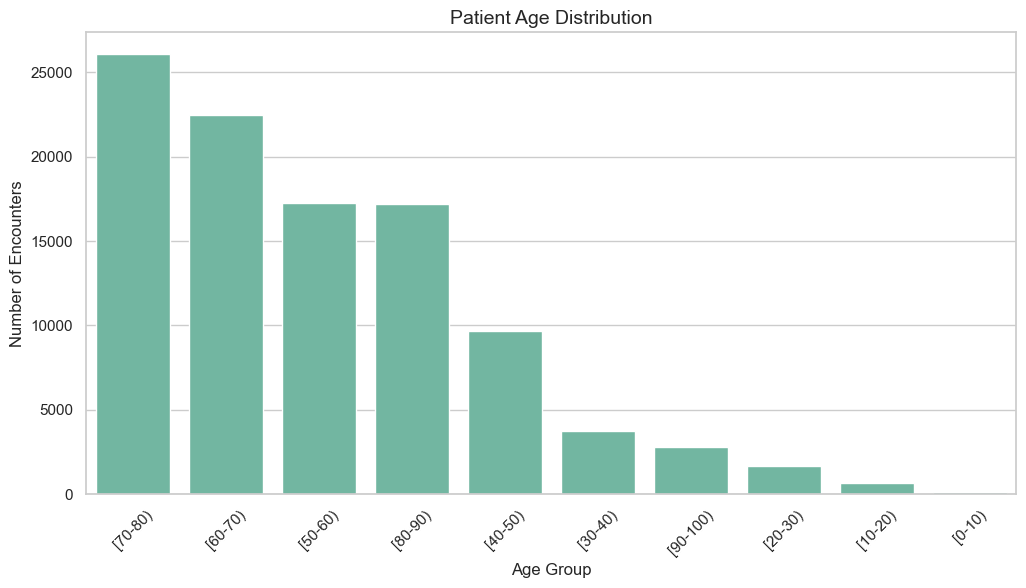

In [10]:
# ============================================
# AGE DISTRIBUTION CHART
# ============================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="age",
    order=df["age"].value_counts().index
)

plt.title("Patient Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Encounters")

plt.xticks(rotation=45)

plt.show()

#####
Healthcare utilization generally increases with age.

Hospitals often focus on:

- elderly populations
- chronic disease management
- readmission reduction programs
- Consequence if Skipped

We may miss important demographic drivers of readmission.

#### Gender Distribution
#####
Gender analysis helps determine whether the dataset is balanced and whether healthcare utilization differs across genders.

In [11]:
# ============================================
# GENDER DISTRIBUTION
# ============================================

gender_counts = df["gender"].value_counts()

gender_counts

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

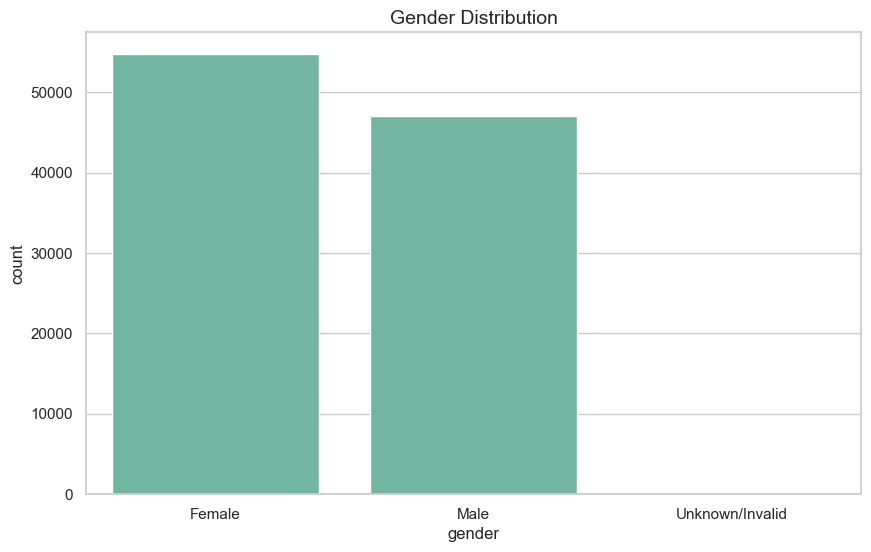

In [12]:
# ============================================
# GENDER DISTRIBUTION CHART
# ============================================

sns.countplot(
    data=df,
    x="gender",
    order=df["gender"].value_counts().index
)

plt.title("Gender Distribution")

plt.show()

#### Race Distribution
#####
Race demographics help understand the composition of the patient population and may reveal healthcare utilization differences across groups.

In [13]:
# ============================================
# RACE DISTRIBUTION
# ============================================

race_counts = df["race"].value_counts()

race_counts

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

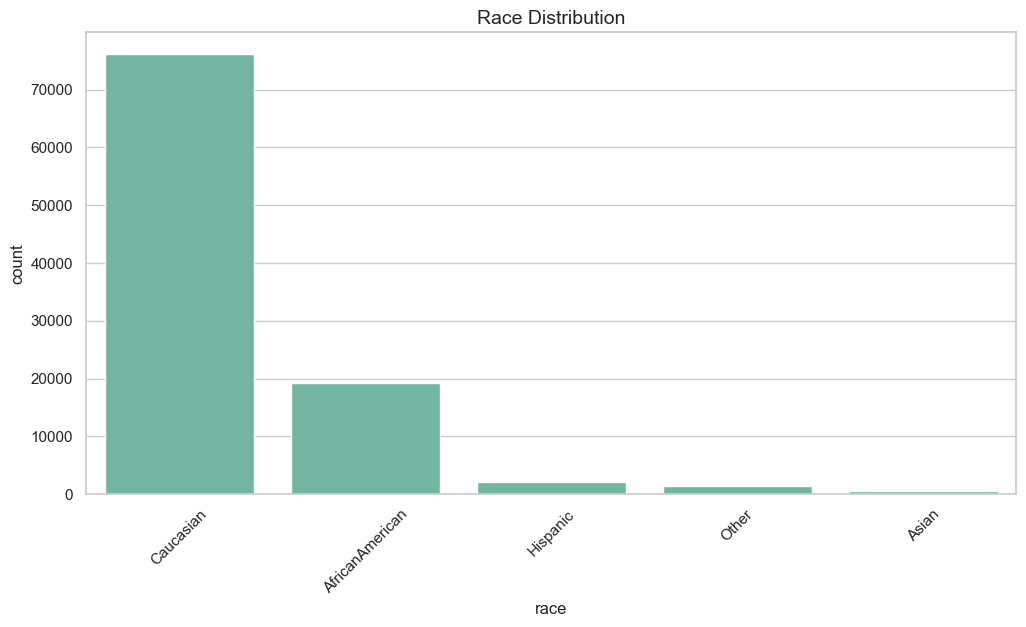

In [14]:
# ============================================
# RACE DISTRIBUTION CHART
# ============================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="race",
    order=df["race"].value_counts().index
)

plt.title("Race Distribution")

plt.xticks(rotation=45)

plt.show()

#### Hospital Stay KPI

##### Length of Stay Analysis

Length of stay is a key operational healthcare metric.

Longer stays often indicate:

- more severe conditions
- increased hospital costs
- greater care complexity

In [15]:
# ============================================
# LENGTH OF STAY KPI
# ============================================

avg_los = df["time_in_hospital"].mean()

print(f"Average Length of Stay: {avg_los:.2f} days")

Average Length of Stay: 4.40 days


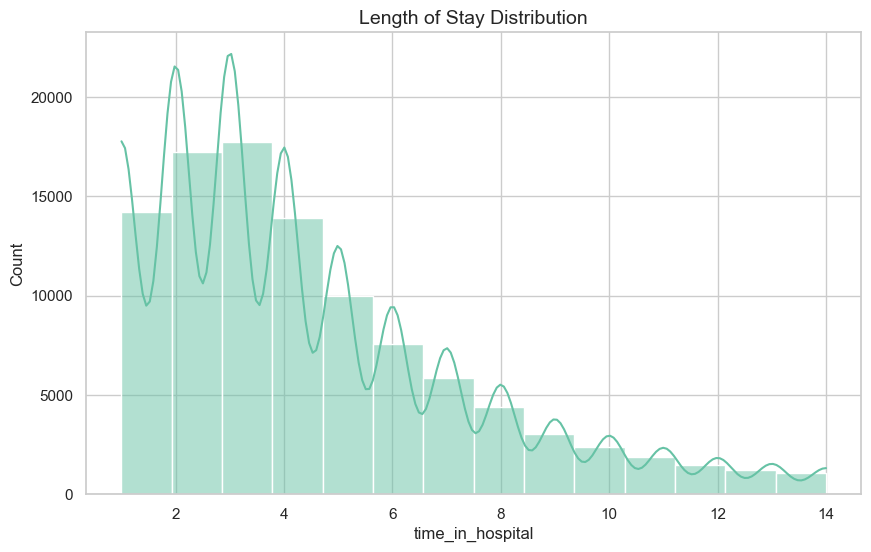

In [16]:
# ============================================
# LENGTH OF STAY DISTRIBUTION
# ============================================

sns.histplot(
    df["time_in_hospital"],
    bins=14,
    kde=True
)

plt.title("Length of Stay Distribution")

plt.show()

##### Create KPI Summary Table

In [17]:
# ============================================
# HEALTHCARE KPI SUMMARY
# ============================================

kpi_summary = pd.DataFrame({

    "Metric": [
        "Total Encounters",
        "Unique Patients",
        "Overall Readmission Rate",
        "Average Length of Stay"
    ],

    "Value": [
        len(df),
        df["patient_nbr"].nunique(),
        round(df["readmitted_flag"].mean()*100, 2),
        round(df["time_in_hospital"].mean(), 2)
    ]

})

kpi_summary

,Metric,Value
0,Total Encounters,101766.00
1,Unique Patients,71518.00
2,Overall Readmission Rate,46.09
3,Average Length of Stay,4.40


##### 
Why This Section Matters

This KPI table will later become:

SQL Dashboard Views:

CREATE VIEW executive_kpis AS ...

Power BI KPI Cards:
- Total Encounters
- Unique Patients
- Readmission Rate
- Average LOS

Streamlit Metrics:

st.metric(...)

In [18]:
age_counts.head(10)

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [19]:
gender_counts

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [20]:
race_counts.head(10)

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [21]:
avg_los

np.float64(4.395986871843248)

In [22]:
kpi_summary

,Metric,Value
0,Total Encounters,101766.00
1,Unique Patients,71518.00
2,Overall Readmission Rate,46.09
3,Average Length of Stay,4.40


Healthcare Insights

1. Age Distribution

| Age Group | Encounters |
| --------- | ---------: |
| 70–80     |     26,068 |
| 60–70     |     22,483 |
| 50–60     |     17,256 |
| 80–90     |     17,197 |
| 40–50     |      9,685 |

Business Interpretation:

The dataset is heavily concentrated among older adults.

50+ years old = majority of encounters

This is expected because:

- diabetes prevalence increases with age
- older patients have more chronic conditions
- older patients typically have higher hospitalization rates
- Healthcare Insight

Patients aged: 60–80 years

represent the largest healthcare utilization group.

This will likely become one of our strongest readmission predictors during machine learning.

2. Gender Distribution

| Gender  |  Count |
| ------- | -----: |
| Female  | 54,708 |
| Male    | 47,055 |
| Unknown |      3 |

Business Interpretation:

The dataset is relatively balanced.

Female encounters are slightly higher.

Healthcare Insight

Gender is unlikely to cause severe modeling bias because both groups are well represented.

3. Race Distribution

| Race             |  Count |
| ---------------- | -----: |
| Caucasian        | 76,099 |
| African American | 19,210 |
| Hispanic         |  2,037 |
| Other            |  1,506 |
| Asian            |    641 |


Business Interpretation:

The dataset is dominated by Caucasian patients.

Important Note:

This does not mean Caucasian patients have higher risk.

It simply means they represent most encounters in this dataset.

We must be careful not to confuse representation with risk.


4. Length of Stay KPI

Average: 4.40 days

Healthcare Interpretation:

This is a realistic average hospital stay.

Hospitals monitor LOS because:

- longer stays increase cost
- longer stays consume resources
- longer stays often indicate greater severity

Future Analysis

We will later investigate:

Does longer hospital stay increase readmission risk?

This is one of the most important questions in healthcare analytics.

Executive KPI Summary:

| KPI                |     Value |
| ------------------ | --------: |
| Total Encounters   |   101,766 |
| Unique Patients    |    71,518 |
| Readmission Rate   |    46.09% |
| Avg Length of Stay | 4.40 Days |

#### Hospital Utilization Analysis.

Emergency Visit Analysis

Emergency visits are a key indicator of healthcare utilization.

Patients with frequent emergency visits may have:

- higher disease severity
- poorer disease management
- increased readmission risk

In [23]:
# ============================================
# EMERGENCY VISITS
# ============================================

df["number_emergency"].describe()

count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64

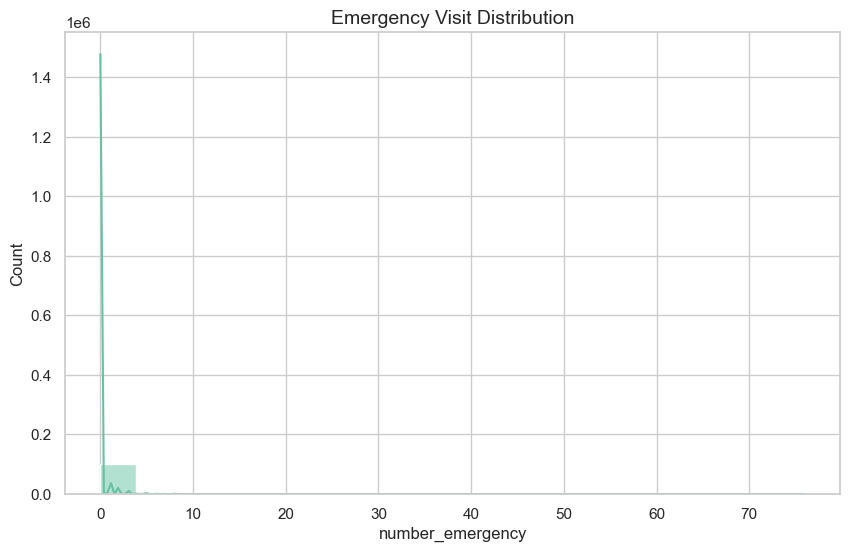

In [24]:
# Chart
sns.histplot(
    df["number_emergency"],
    bins=20,
    kde=True
)

plt.title("Emergency Visit Distribution")

plt.show()

Inpatient Visit Analysis

Inpatient visits represent previous hospital admissions.

A higher number of inpatient visits may indicate chronic conditions or recurring healthcare needs.

In [25]:
# ============================================
# INPATIENT VISITS
# ============================================

df["number_inpatient"].describe()

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

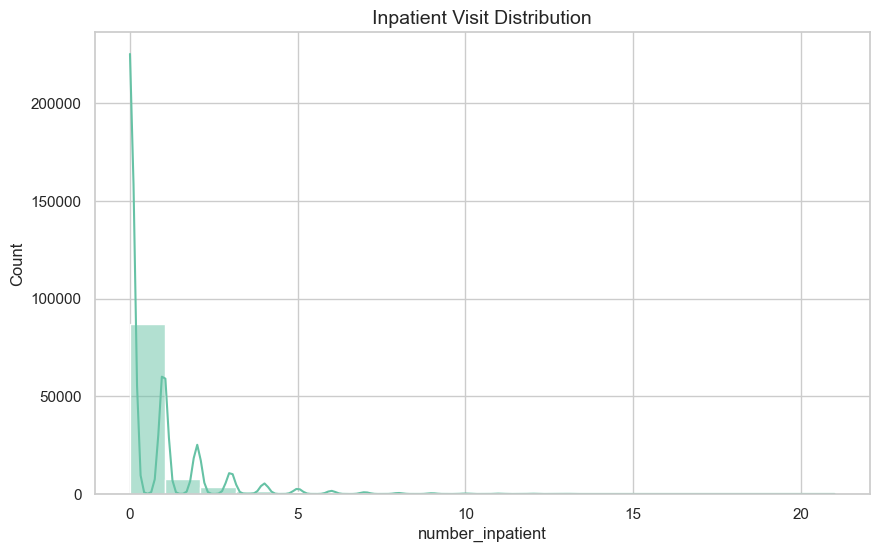

In [26]:
# Chart
sns.histplot(
    df["number_inpatient"],
    bins=20,
    kde=True
)

plt.title("Inpatient Visit Distribution")

plt.show()

Outpatient Visit Analysis

Outpatient visits represent healthcare interactions that do not require hospital admission.

These visits may indicate ongoing disease management.

In [27]:
# ============================================
# OUTPATIENT VISITS
# ============================================

df["number_outpatient"].describe()

count    101766.000000
mean          0.369357
std           1.267265
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          42.000000
Name: number_outpatient, dtype: float64

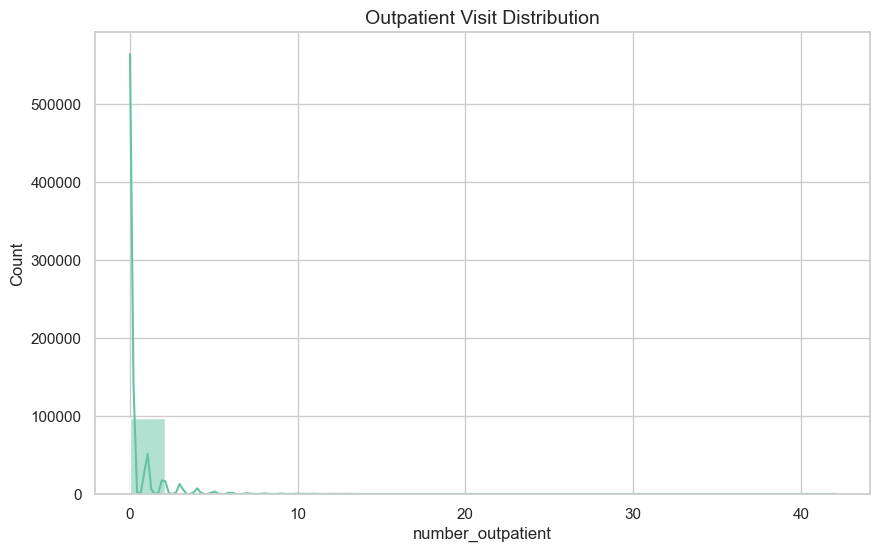

In [28]:
# Chart
sns.histplot(
    df["number_outpatient"],
    bins=20,
    kde=True
)

plt.title("Outpatient Visit Distribution")

plt.show()

Medication Count Analysis

The number of medications may reflect treatment complexity and disease severity.

Patients taking many medications may require more intensive care management.

In [29]:
# ============================================
# MEDICATION COUNT
# ============================================

df["num_medications"].describe()

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

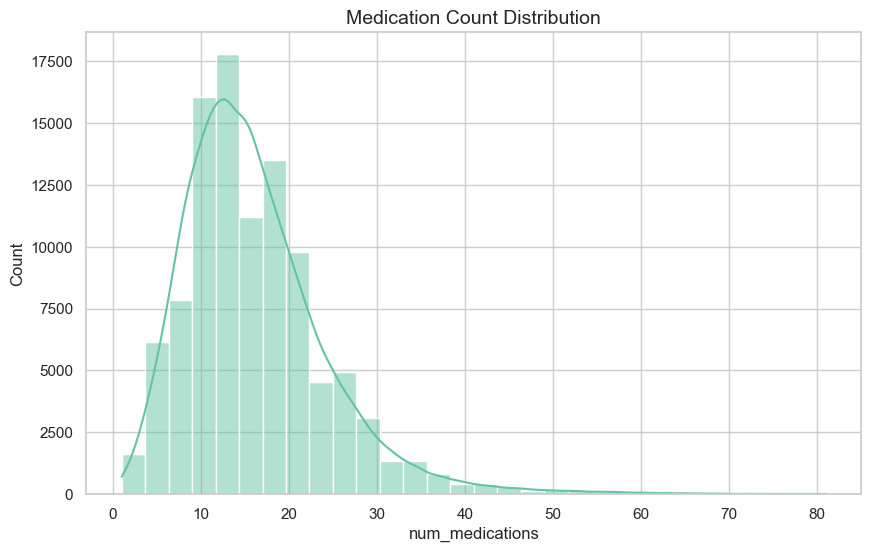

In [30]:
# Chart
sns.histplot(
    df["num_medications"],
    bins=30,
    kde=True
)

plt.title("Medication Count Distribution")

plt.show()

Healthcare Utilization Analysis

These four variables are likely to become important predictors in our future machine learning model.

1. Emergency Visits

| Statistic | Value |
| --------- | ----: |
| Average   |  0.20 |
| Median    |     0 |
| Max       |    76 |

Business Interpretation:

Most patients had: 0 emergency visits before the current encounter.

However, a small group had very high emergency utilization.

Example:

Maximum = 76 emergency visits

This suggests a subset of high-risk patients who frequently require urgent care.

Healthcare Insight:

Frequent emergency visits often indicate:

- poor disease management
- chronic complications
- higher readmission risk


2. Inpatient Visits

| Statistic | Value |
| --------- | ----: |
| Average   |  0.64 |
| Median    |     0 |
| Max       |    21 |

Business Interpretation:

Most patients had: 0 previous inpatient visits

but some patients had repeated hospitalizations.

Healthcare Insight:

This may become one of our strongest predictors.

Why?

Patients who were hospitalized previously are often more likely to be hospitalized again.

Hospitals frequently use prior inpatient history when assessing patient risk.

3. Outpatient Visits

| Statistic | Value |
| --------- | ----: |
| Average   |  0.37 |
| Median    |     0 |
| Max       |    42 |

Business Interpretation:

Most patients had limited outpatient utilization.

A smaller subset interacts heavily with healthcare services.

Healthcare Insight:

This could have two interpretations:

Positive

More outpatient care may help prevent readmissions.

Negative

Frequent outpatient visits may indicate severe disease.

4. Medication Count

| Statistic | Value |
| --------- | ----: |
| Average   | 16.02 |
| Median    |    15 |
| Max       |    81 |

Business Interpretation: 

Patients in this dataset are taking many medications.

Average:

16 medications is substantial.

Healthcare Insight:

Higher medication counts often indicate:

- multiple chronic conditions
- more complex treatment plans
- increased risk of medication errors
- greater care complexity

This variable will almost certainly be important in machine learning.

Healthcare Executive Insights Found So Far

You can already add these to your future README:

Insight 1

Patients aged 60–80 years account for the majority of hospital encounters.

Insight 2

Overall readmission rate is 46.09%.

Insight 3

Average hospital stay is 4.4 days.

Insight 4

A small subset of patients account for disproportionately high emergency, inpatient, and outpatient utilization.

Insight 5

Patients receive an average of 16 medications per encounter, indicating substantial treatment complexity.

#### Readmission Rate by Prior Inpatient Visits

Readmission vs Previous Inpatient Visits

Previous inpatient visits may indicate recurring healthcare needs.

This analysis evaluates whether patients with more prior hospitalizations experience higher readmission rates.

In [31]:
# ============================================
# READMISSION VS INPATIENT VISITS
# ============================================

inpatient_readmission = (
    df.groupby("number_inpatient")["readmitted_flag"]
      .mean()
      .reset_index()
)

inpatient_readmission["readmission_rate"] = (
    inpatient_readmission["readmitted_flag"] * 100
)

inpatient_readmission.head(10)

,number_inpatient,readmitted_flag,readmission_rate
0,0,0.384948,38.494751
1,1,0.547615,54.761539
2,2,0.649352,64.935237
3,3,0.697156,69.715626
4,4,0.742293,74.229346
5,5,0.800493,80.049261
6,6,0.841667,84.166667
7,7,0.809701,80.970149
8,8,0.907285,90.728477
9,9,0.882883,88.288288


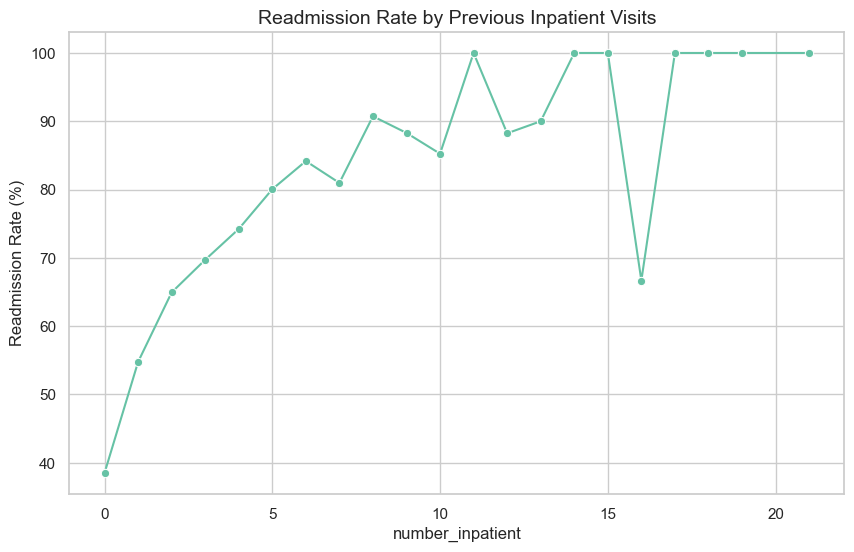

In [32]:
# Chart
plt.figure(figsize=(10,6))

sns.lineplot(
    data=inpatient_readmission,
    x="number_inpatient",
    y="readmission_rate",
    marker="o"
)

plt.title(
    "Readmission Rate by Previous Inpatient Visits"
)

plt.ylabel("Readmission Rate (%)")

plt.show()

Readmission Rate by Medication Count

In [33]:
medication_readmission = (
    df.groupby("num_medications")["readmitted_flag"]
      .mean()
      .reset_index()
)

medication_readmission["readmission_rate"] = (
    medication_readmission["readmitted_flag"] * 100
)

medication_readmission.head(10)

,num_medications,readmitted_flag,readmission_rate
0,1,0.316794,31.679389
1,2,0.308511,30.851064
2,3,0.304444,30.444444
3,4,0.349330,34.932957
4,5,0.340605,34.060486
5,6,0.377177,37.717673
6,7,0.393513,39.351320
7,8,0.406386,40.638640
8,9,0.423977,42.397720
9,10,0.430602,43.060232


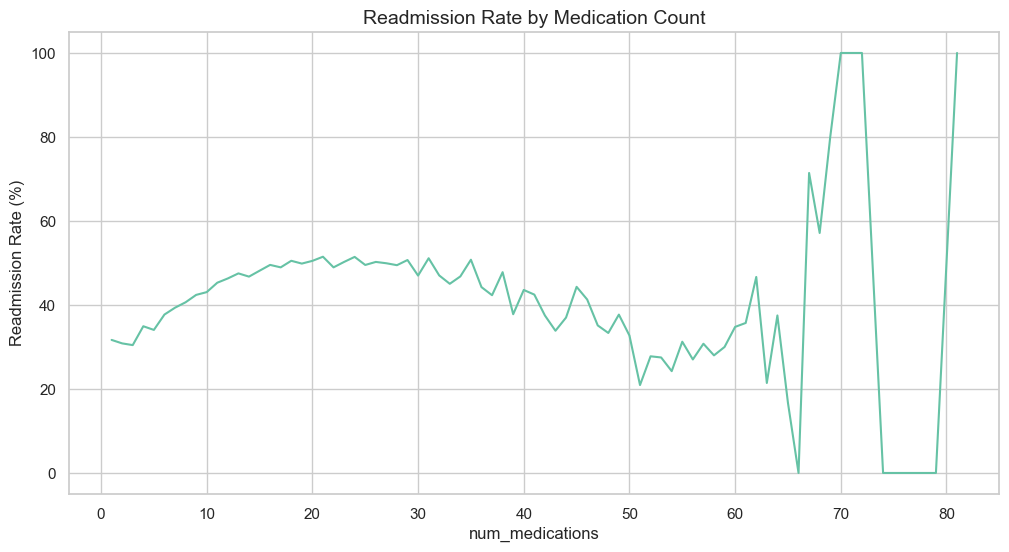

In [34]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=medication_readmission,
    x="num_medications",
    y="readmission_rate"
)

plt.title(
    "Readmission Rate by Medication Count"
)

plt.ylabel("Readmission Rate (%)")

plt.show()

Insight 1: Previous Inpatient Visits Are Strongly Associated with Readmission

| Previous Inpatient Visits | Readmission Rate |
| ------------------------- | ---------------: |
| 0                         |            38.5% |
| 1                         |            54.8% |
| 2                         |            64.9% |
| 3                         |            69.7% |
| 4                         |            74.2% |
| 5                         |            80.0% |
| 6                         |            84.2% |
| 7                         |            81.0% |
| 8                         |            90.7% |
| 9                         |            88.3% |

Business Interpretation:

This is one of the strongest patterns we have seen.

Patients with: 0 previous inpatient visits have a readmission rate of about: 38.5%

Patients with: 8 previous inpatient visits have a readmission rate of: 90.7%

Healthcare Insight: 

Prior hospitalization history appears to be a major risk factor for future readmissions.

This is exactly the type of finding hospitals use when building patient risk stratification systems.

Machine Learning Insight:

number_inpatient will likely become one of the most important model features later.

Insight 2: Medication Count Is Associated with Readmission

| Medication Count | Readmission Rate |
| ---------------- | ---------------: |
| 1                |            31.7% |
| 5                |            34.1% |
| 10               |            43.1% |

And the chart should show a general upward trend.

Business Interpretation

Patients taking more medications tend to experience higher readmission rates.

Healthcare Insight

Medication count may be acting as a proxy for:

- disease severity
- treatment complexity
- multiple chronic conditions
- Machine Learning Insight

num_medications is likely to be another highly predictive feature.

Executive-Level Findings So Far

You now have several portfolio-quality insights:

Finding 1:

Overall readmission rate is: 46.09%

Finding 2:

Patients aged: 60–80 years represent the largest patient population.

Finding 3:

Average hospital stay: 4.4 days

Finding 4:

Patients with multiple prior inpatient visits experience dramatically higher readmission rates.

Finding 5:

Higher medication counts are associated with increased readmission risk.

In [35]:
df["diag_1"].value_counts().head(20)

diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64

The values:

428
414
786
410
486
427
...

are ICD-9 diagnosis codes, not diagnosis names.

| ICD-9 Code | Typical Diagnosis                          |
| ---------- | ------------------------------------------ |
| 428        | Heart Failure                              |
| 414        | Coronary Atherosclerosis                   |
| 410        | Acute Myocardial Infarction (Heart Attack) |
| 486        | Pneumonia                                  |
| 427        | Cardiac Dysrhythmias                       |
| 250.x      | Diabetes-related conditions                |
| 584        | Acute Kidney Failure                       |
| 599        | Urinary Tract Disorders                    |


Let's create a diagnosis category feature for better macchine learning features and better business story telling

#### Diagnosis Category Engineering

Diagnosis Category Analysis

The primary diagnosis field contains ICD-9 codes.

To improve interpretability, diagnoses will be grouped into broader healthcare categories.

This allows easier reporting and dashboard development.

In [36]:
# ============================================
# DIAGNOSIS CATEGORY FUNCTION
# ============================================

def categorize_diagnosis(diag):

    try:

        diag = float(diag)

        if 390 <= diag <= 459:
            return "Circulatory"

        elif 460 <= diag <= 519:
            return "Respiratory"

        elif 520 <= diag <= 579:
            return "Digestive"

        elif 580 <= diag <= 629:
            return "Genitourinary"

        elif 250 <= diag < 251:
            return "Diabetes"

        elif 800 <= diag <= 999:
            return "Injury"

        else:
            return "Other"

    except:
        return "Other"

In [37]:
#Apply Function
# ============================================
# CREATE DIAGNOSIS CATEGORY
# ============================================

df["diagnosis_category"] = df["diag_1"].apply(
    categorize_diagnosis
)

df["diagnosis_category"].value_counts()

diagnosis_category
Other            31006
Circulatory      30336
Respiratory      10407
Digestive         9208
Diabetes          8757
Injury            6974
Genitourinary     5078
Name: count, dtype: int64

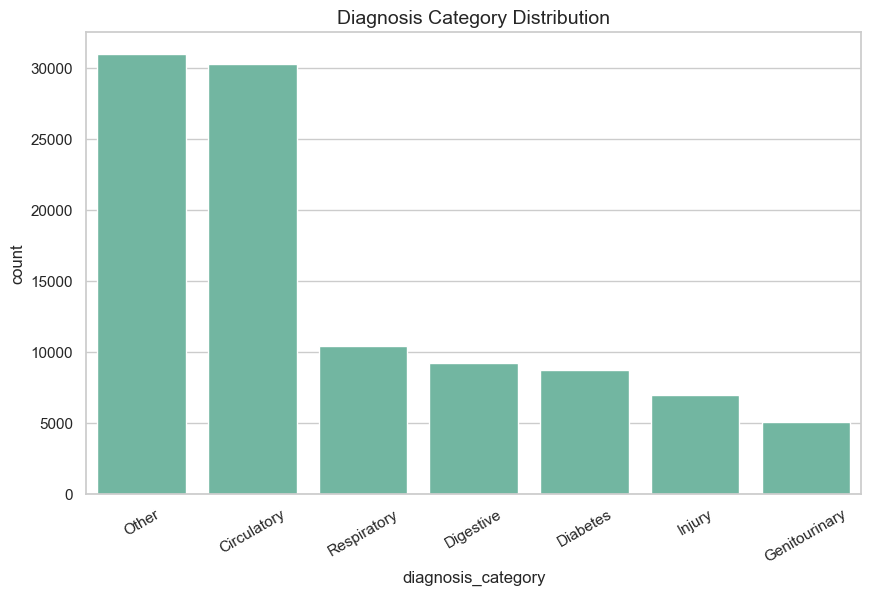

In [38]:
# Visualization
# ============================================
# DIAGNOSIS CATEGORY DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="diagnosis_category",
    order=df["diagnosis_category"].value_counts().index
)

plt.title("Diagnosis Category Distribution")

plt.xticks(rotation=30)

plt.show()

Why We Do This:
Raw ICD Codes
428
414
410
are difficult for business users to understand.

Categories
Circulatory
Respiratory
Diabetes
are dashboard-friendly.

Consequence if Skipped:
Power BI dashboard
Streamlit dashboard
README
interview explanations
become much harder to understand.

Readmission Rate by Diagnosis Category

In [39]:
# ============================================
# READMISSION BY DIAGNOSIS CATEGORY
# ============================================

diag_readmission = (

    df.groupby("diagnosis_category")[
        "readmitted_flag"
    ]

    .mean()

    .reset_index()

)

diag_readmission["readmission_rate"] = (
    diag_readmission["readmitted_flag"] * 100
)

diag_readmission.sort_values(
    by="readmission_rate",
    ascending=False
)

,diagnosis_category,readmitted_flag,readmission_rate
1,Diabetes,0.508736,50.873587
6,Respiratory,0.502162,50.216201
0,Circulatory,0.471057,47.105749
2,Digestive,0.459275,45.927454
4,Injury,0.443218,44.321767
3,Genitourinary,0.442891,44.289090
5,Other,0.430949,43.094885


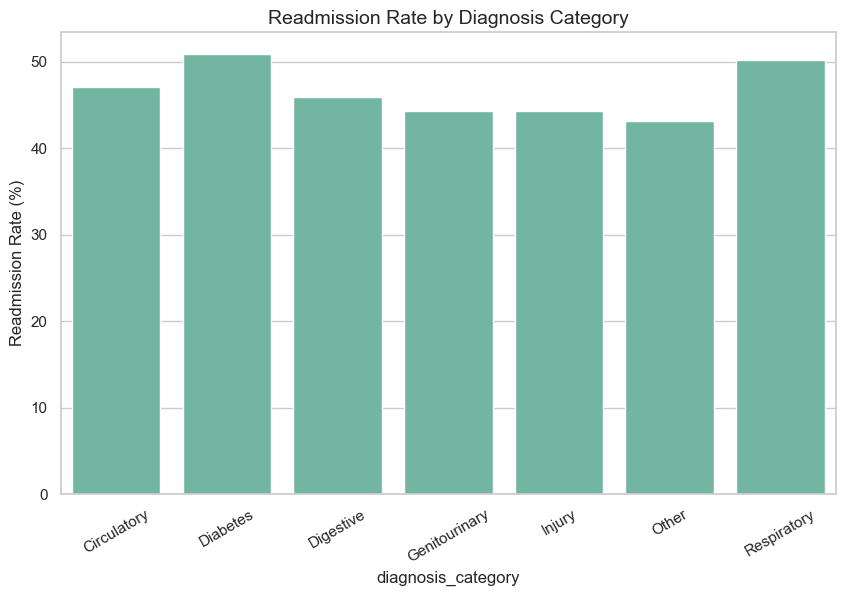

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=diag_readmission,
    x="diagnosis_category",
    y="readmission_rate"
)

plt.title(
    "Readmission Rate by Diagnosis Category"
)

plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [41]:
df["diagnosis_category"].value_counts()

diagnosis_category
Other            31006
Circulatory      30336
Respiratory      10407
Digestive         9208
Diabetes          8757
Injury            6974
Genitourinary     5078
Name: count, dtype: int64

In [42]:
diag_readmission.sort_values(
    by="readmission_rate",
    ascending=False
)

,diagnosis_category,readmitted_flag,readmission_rate
1,Diabetes,0.508736,50.873587
6,Respiratory,0.502162,50.216201
0,Circulatory,0.471057,47.105749
2,Digestive,0.459275,45.927454
4,Injury,0.443218,44.321767
3,Genitourinary,0.442891,44.289090
5,Other,0.430949,43.094885


Diagnosis Analysis Results

Diagnosis Distribution

| Category      | Encounters |
| ------------- | ---------: |
| Other         |     31,006 |
| Circulatory   |     30,336 |
| Respiratory   |     10,407 |
| Digestive     |      9,208 |
| Diabetes      |      8,757 |
| Injury        |      6,974 |
| Genitourinary |      5,078 |



Healthcare Insight #6

The two largest diagnosis groups are:

- Circulatory Diseases
- Other Conditions

Circulatory diseases include:

- heart failure
- coronary artery disease
- hypertension-related complications
- cardiovascular disorders

This aligns with real-world healthcare utilization patterns.

Readmission Rate by Diagnosis Category

| Category      | Readmission Rate |
| ------------- | ---------------: |
| Diabetes      |           50.87% |
| Respiratory   |           50.22% |
| Circulatory   |           47.11% |
| Digestive     |           45.93% |
| Injury        |           44.32% |
| Genitourinary |           44.29% |
| Other         |           43.09% |


Healthcare Insight #7

Patients with: Diabetes-related diagnoses experienced the highest readmission rate: 50.87%

This is extremely relevant because the dataset itself is diabetes-focused.

Healthcare Insight #8

Respiratory conditions also show elevated readmission risk: 50.22%

Examples include:

- pneumonia
- chronic respiratory diseases
- pulmonary complications

These conditions often require repeated healthcare interventions.

Healthcare Insight #9

Circulatory diseases represent:

- one of the largest diagnosis groups
- one of the highest readmission groups

This makes them a high-priority population for hospital readmission reduction programs.

Finding 6:

Diabetes diagnoses have the highest readmission rate.

Finding 7:

Respiratory diseases also have elevated readmission risk.

Finding 8:

Circulatory diseases represent one of the largest patient populations.

#### Diabetes Medication Usage

Diabetes Medication Analysis

The dataset contains information about whether patients were prescribed diabetes medications.

Understanding medication usage can help identify treatment patterns and patient management strategies.

In [43]:
# ============================================
# DIABETES MEDICATION USAGE
# ============================================

diabetes_med_counts = (
    df["diabetesMed"]
    .value_counts()
)

diabetes_med_counts

diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

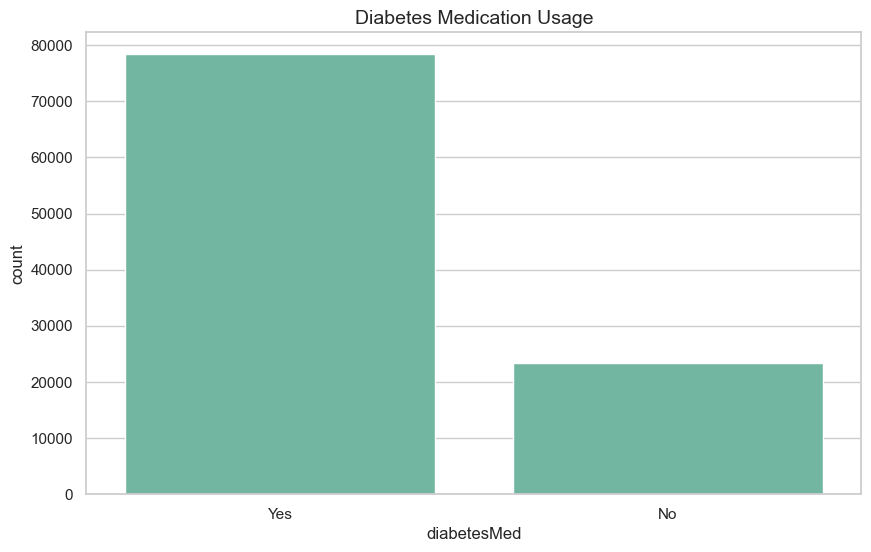

In [44]:
sns.countplot(
    data=df,
    x="diabetesMed",
    order=df["diabetesMed"].value_counts().index
)

plt.title(
    "Diabetes Medication Usage"
)

plt.show()

Medication Change Analysis

The change variable indicates whether a patient's diabetes medication regimen changed during the encounter.

Medication adjustments may be associated with disease management and future healthcare outcomes.

In [45]:
# ============================================
# MEDICATION CHANGES
# ============================================

change_counts = (
    df["change"]
    .value_counts()
)

change_counts

change
No    54755
Ch    47011
Name: count, dtype: int64

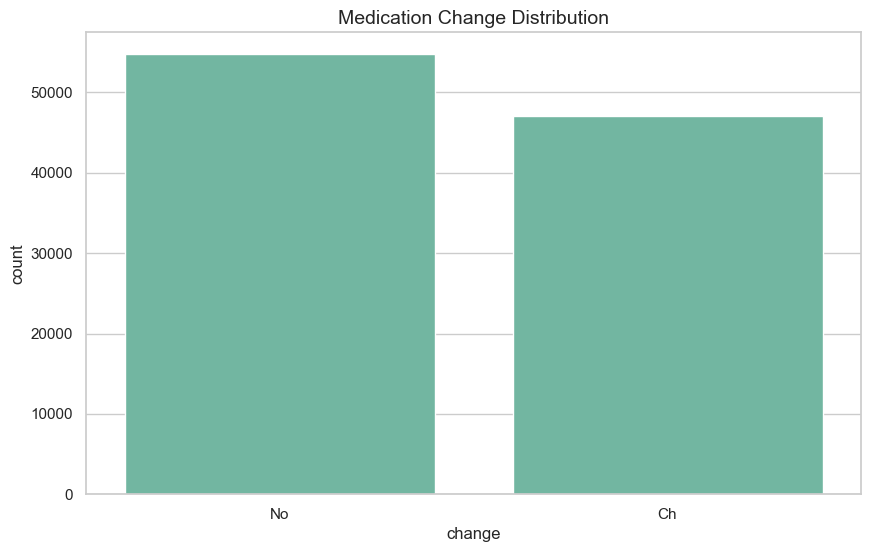

In [46]:
sns.countplot(
    data=df,
    x="change",
    order=df["change"].value_counts().index
)

plt.title(
    "Medication Change Distribution"
)

plt.show()

Readmission by Medication Change

In [47]:
# ============================================
# READMISSION BY MEDICATION CHANGE
# ============================================

change_readmission = (

    df.groupby("change")[
        "readmitted_flag"
    ]

    .mean()

    .reset_index()

)

change_readmission["readmission_rate"] = (
    change_readmission["readmitted_flag"] * 100
)

change_readmission

,change,readmitted_flag,readmission_rate
0,Ch,0.485631,48.563102
1,No,0.439631,43.963108


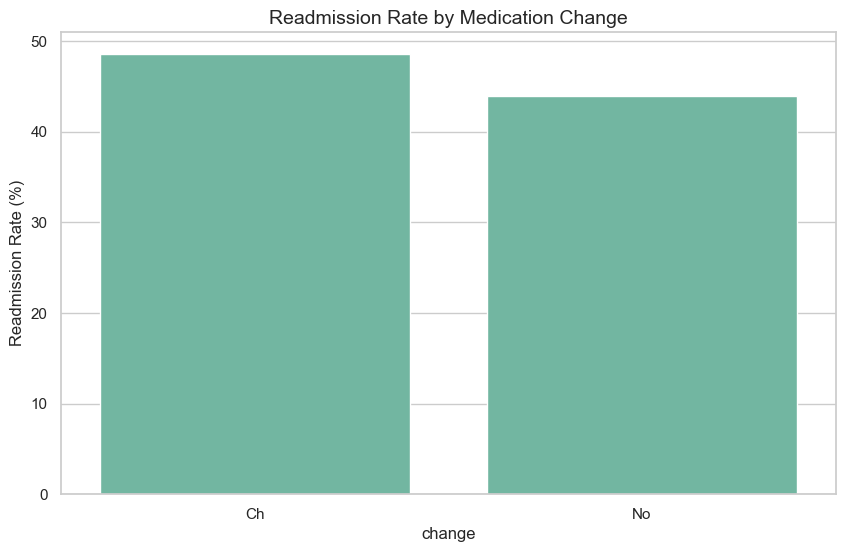

In [48]:
sns.barplot(
    data=change_readmission,
    x="change",
    y="readmission_rate"
)

plt.title(
    "Readmission Rate by Medication Change"
)

plt.ylabel(
    "Readmission Rate (%)"
)

plt.show()

Medication Analysis Results:

Diabetes Medication Usage

| Diabetes Medication |  Count |
| ------------------- | -----: |
| Yes                 | 78,363 |
| No                  | 23,403 |

Healthcare Insight #10

Approximately: 77% of encounters involved diabetes medication.

This confirms that the dataset primarily represents actively managed diabetes patients.

Medication Change Analysis

Medication Change

| Medication Change |  Count |
| ----------------- | -----: |
| No Change         | 54,755 |
| Changed           | 47,011 |

Healthcare Insight #11

Nearly half of all encounters involved a medication adjustment.

This suggests:

- active treatment management
- medication optimization
- physician intervention during hospitalization

Readmission by Medication Change

| Medication Change | Readmission Rate |
| ----------------- | ---------------: |
| Changed           |           48.56% |
| No Change         |           43.96% |

Healthcare Insight #12

Patients whose medications were changed experienced a higher readmission rate.

Difference:

48.56% - 43.96% = 4.60 percentage points
Important Healthcare Interpretation

Do NOT conclude:

Medication changes cause readmissions.

More likely:

Patients requiring medication changes are often more clinically complex.

Medication change is probably acting as a proxy for:

- disease severity
- unstable glucose control
- treatment complexity

This is exactly the type of variable that often becomes important in predictive models.

Finding 9

77% of encounters involve diabetes medication treatment.

Finding 10

Patients with medication changes exhibit higher readmission rates.

In [49]:
import os

os.makedirs("../outputs", exist_ok=True)

In [50]:
kpi_summary.to_csv(
    "../outputs/kpi_summary.csv",
    index=False
)

diag_readmission.to_csv(
    "../outputs/diagnosis_readmission_summary.csv",
    index=False
)

change_readmission.to_csv(
    "../outputs/medication_change_readmission.csv",
    index=False
)

print("EDA outputs saved successfully.")

EDA outputs saved successfully.


### Executive Summary

#### Key Insights
#####
1. Overall readmission rate is 46.09%.
2. Patients aged 60–80 years account for the largest share of encounters.
3. Average hospital length of stay is 4.4 days.
4. Previous inpatient visits are strongly associated with readmission risk.
5. Patients taking more medications generally experience higher readmission rates.
6. Diabetes-related diagnoses have the highest observed readmission rate.
7. Respiratory diseases also show elevated readmission risk.
8. Most patients receive diabetes medication therapy.
9. Medication changes are associated with higher readmission rates.

#### Business Impact
#####
These findings can help hospitals:

- identify high-risk patient populations
- improve discharge planning
- prioritize care management resources
- develop readmission reduction programs

##### Next Steps

The next notebook will focus on feature engineering and machine learning preparation.